# The minimal active vision demo. 
The first very simple progression, focusing on biological plausibility + possible iCub-compatibility.  
__Goals of this demo:__ test DINO patch encoding, observe how the memory changes during observation, check if the objects are more similar to themselves than to other objects.   
Find out if the binding strategy is suitable.      

- Exploration:   
    - Rendering objects from the CRIB dataset using Mujoco.
    - Wrist(object) rotation is fixed to a basic pan-tilt sequence, fixed for all objects. 
    - Converting RGB to events using the IEBCS library.  
    - Using lightweight approximation of the attention mechanism on the events. (This one is problematic, the attention should highlight the whole object, putting the most salient point to the center of object. Currently, it highlights edges, which we already have from events.)
    - __Exploratory behavior:__ 50% probability of fixating at the most salient point,  
    50% probability of fixating at a random point, where the saliency is > 100 (max saliency: 255).  
    - __Vision:__ foveated vision, high-resolution ROI (approx. 2 cm, reflects 20 cm observation distance of the object) + downsampled periphery (currently uniformly downsampled - inaccurate).    
- Encoding of the sensorimotor input:
    - patch: encoded using a DINOv2 embedding normalized in the ssp manner (unitary norm and Fourier components) 
    - x, y position of saccade center: VSA encoding (x, y as visual angle eccentricity in the patch) 
    - rotation: VSA encoding of rotation the angle-axis form [angle, u_x, u_y, u_z]   
    - Binding: patch_DINO $\circledast$ position $\circledast$ rotation  
- Working memory update and time:  
    - Exponential moving average-based update. Currently GAMMA = 0.9999 because I am a bit unsure about the EMA approach at the moment.

### What the code does: 
- Rotates and renders the object, collecting sensory input for the VSA memory.  
- Updating basic Working memory.  
- Animating rotating object in RGB and events, animating saliency map and foveation.  
- Visualising PCA and t-SNE of the memory state history to build intuition of if and how the memory is evolving.  

I collected multiple memories of fish, camel, and apple objects, and saved them into ./object_memories. I collected explorations with always pickingthe most salient point and also randomized exploration, with 0.5 random exploratory rate over the object. 



In [119]:
import mujoco
import numpy as np
import cv2
import sys
import torch
import torchvision.transforms as T
from PIL import Image
from time import sleep
from IPython.display import display, clear_output
import sspspace
import matplotlib.pyplot as plt
import numpy as np
import cv2

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Add IEBCS to path
sys.path.append("IEBCS/src")
from dvs_sensor import DvsSensor
from event_buffer import EventBuffer

from attention_helpers import initialise_attention, run_attention


In [120]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
ATTN = initialise_attention(device, {
    'size_krn': 16, 'r0': 14, 'rho': 0.05, 'theta': np.pi*3/2,
    'thetas': np.arange(0, 2*np.pi, np.pi/4), 'thick': 3,
    'fltr_resize_perc': [2, 2], 'offsetpxs': 0, 'offset': (0, 0),
    'num_pyr': 6, 'tau_mem': 0.3, 'stride': 1, 'out_ch': 1
})
to_tensor = T.Compose([T.ToTensor()])

WIDTH, HEIGHT = 640, 480
DT_us = 1000 #(≈30 Hz)  # time interval of event integration in [us] 
DOWNSAMPLE_FACTOR = 0.05 # downsampling of the periphery
RADIUS = 77 // 2  # 77 px diameter of the foveated area (~2 cm)

SSP_DIM = 384
MEMORY_GAMMA = 0.99999 # decay factor for working memory
START_TSNE_COUNT = 30  # start t-SNE visualisation after these many saccades

dvs = DvsSensor("RealTimeDVS")
dvs.initCamera(WIDTH, HEIGHT, lat=100, jit=10, ref=100, tau=10, th_pos=0.4, th_neg=0.4, th_noise=0.1, bgnp=0.01, bgnn=0.01)


### __Event generation__

In [121]:
class EventFrameRendererWindow:
    # rendering just the latest timewindow of events
    def __init__(self, width, height, tau):
        self.width, self.height = width, height
        self.window_us = tau
        self.now = 0

    def update(self, events, dt_us):
        self.now += dt_us

        # pozadí = 128 (žádná událost)
        img = np.full((self.height, self.width), 0, dtype=np.uint8)

        if events.i > 0:
            mask = events.ts[:events.i] >= (self.now - self.window_us)
            x = events.x[:events.i][mask]
            y = events.y[:events.i][mask]
            p = events.p[:events.i][mask]

            # do not distinguish polarity of events
            img[y[p == 1], x[p == 1]] = 255   # ON
            img[y[p == 0], x[p == 0]] = 255    

        return cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)


### __Object manipulation and scene setup__

In [122]:
def quaternion_from_axis_angle(axis, ang_rad):
    ax = np.asarray(axis, dtype=np.float64)
    ax = ax / (np.linalg.norm(ax) + 1e-12)
    s = np.sin(ang_rad/2.0)
    return np.array([np.cos(ang_rad/2.0), ax[0]*s, ax[1]*s, ax[2]*s], dtype=np.float64)  # [w,x,y,z]

def quaternion_mul(q2, q1):
    # Hamilton product. Applies q = q2 ⊗ q1  (q1 first, then q2)
    w1,x1,y1,z1 = q1; w2,x2,y2,z2 = q2
    return np.array([
        w2*w1 - x2*x1 - y2*y1 - z2*z1,
        w2*x1 + x2*w1 + y2*z1 - z2*y1,
        w2*y1 - x2*z1 + y2*w1 + z2*x1,
        w2*z1 + x2*y1 - y2*x1 + z2*w1
    ], dtype=np.float64)

def set_pitch_roll_quat(data, pitch_deg, roll_deg):
    # local X then local Z: q_total = q_roll ⊗ q_pitch
    q_pitch = quaternion_from_axis_angle([1,0,0], np.deg2rad(pitch_deg))
    q_roll  = quaternion_from_axis_angle([0,0,1], np.deg2rad(roll_deg))
    q_total = quaternion_mul(q_roll, q_pitch)
    data.qpos[3:7] = q_total  # free joint quat [w,x,y,z]

def delta_pitch_roll_quat(pitch_deg, roll_deg):
    q_pitch = quaternion_from_axis_angle([1,0,0], np.deg2rad(pitch_deg))
    q_roll  = quaternion_from_axis_angle([0,0,1], np.deg2rad(roll_deg))
    return quaternion_mul(q_roll, q_pitch)  # roll ⊗ pitch

def get_total_quaternion(pitch_deg, roll_deg, base_q):
    delta = delta_pitch_roll_quat(pitch_deg, roll_deg)   # relative rotation
    q_total = quaternion_mul(base_q,delta)                   
    return q_total / (np.linalg.norm(q_total) + 1e-12)

def quat_to_axis_angle(quat, degrees=False, eps=1e-12):
    """
    Convert quaternion [w,x,y,z] to axis-angle (angle, ux, uy, uz).
    - Returns axis as a unit vector and angle in radians (or degrees if degrees=True).
    - Handles numerical edge cases (small angles).
    """
    q = np.asarray(quat, dtype=np.float64)
    if q.shape[-1] != 4:
        raise ValueError("quat must be length-4 [w,x,y,z]")
    w, x, y, z = q
    # clamp w for numerical safety
    w = np.clip(w, -1.0, 1.0)
    angle = 2.0 * np.arccos(w)
    sin_half = np.sqrt(max(0.0, 1.0 - w*w))
    if sin_half < eps:
        # Angle is ~0, axis is arbitrary; choose normalized vector part if available, else x-axis
        axis = np.array([1.0, 0.0, 0.0], dtype=np.float64)
    else:
        axis = np.array([x, y, z], dtype=np.float64) / sin_half
        axis = axis / (np.linalg.norm(axis) + 1e-16)  # ensure unit numeric
    if degrees:
        angle = np.degrees(angle)
    return  angle, axis[0], axis[1], axis[2]

def to_luminance(rgb_uint8):
    luv = cv2.cvtColor(rgb_uint8, cv2.COLOR_RGB2LUV)
    return (luv[:,:,0].astype(np.float32) / 255.0) * 1e4  # same scaling as before

def make_scene(xml_path,random_rotation=True, max_angle_deg=360):
    model = mujoco.MjModel.from_xml_path(xml_path)
    data  = mujoco.MjData(model)
    renderer = mujoco.Renderer(model, HEIGHT, WIDTH)  # (h, w) order in mujoco.Renderer
    mujoco.mj_resetData(model, data)
    
    if random_rotation:
        # random angles in [-max_angle_deg, +max_angle_deg]
        pitch_init = np.random.uniform(-max_angle_deg, max_angle_deg)
        roll_init  = np.random.uniform(-max_angle_deg, max_angle_deg)
        base_q = delta_pitch_roll_quat(pitch_init, roll_init)
        data.qpos[3:7] = base_q
        print(f"Initial rotation: pitch={pitch_init:.1f}°, roll={roll_init:.1f}°")
    else:
        base_q = data.qpos[3:7].copy()

    mujoco.mj_forward(model, data)
    renderer.update_scene(data)
    return model, data, renderer, base_q

def render_pose(model, data, renderer, base_q, pitch_deg, roll_deg):
    delta = delta_pitch_roll_quat(pitch_deg, roll_deg)   # relative rotation
    q_total = quaternion_mul(base_q,delta)                   
    q_total = q_total / (np.linalg.norm(q_total) + 1e-12)
    data.qpos[3:7] = q_total

    mujoco.mj_forward(model, data)
    renderer.update_scene(data)
    return renderer.render()



### __Saliency and foveation__

In [123]:
def saliency_from_events_bgr(ev_bgr, out_size):
    # ev_bgr is the colored event frame (H,W,3) from EventFrameRenderer
    gray = cv2.cvtColor(abs(ev_bgr), cv2.COLOR_BGR2GRAY)           # uint8
    ten  = to_tensor(gray).to(device)                          # [1,1,H,W], float32 0..1
    S, _ = run_attention(ten, ATTN, device, out_size, num_pyr=6)  # returns float map
    S = S.astype(np.float32)
    m = S.max()
    if m <= 1e-12:                                             # robust normalize
        S8 = np.zeros_like(gray)
    else:
        S = S / m
        S8 = (S * 255.0).clip(0, 255).astype(np.uint8)
    Scolor = cv2.applyColorMap(S8, cv2.COLORMAP_JET)           # colored saliency
    return S8, Scolor

def make_foveated_events_binary(ev_img, x, y, tile=8):
    H, W = ev_img.shape[:2]
    if ev_img.ndim == 2:
        gray = ev_img
    else:
        gray = cv2.cvtColor(ev_img, cv2.COLOR_BGR2GRAY)
    # ON events: anything > 0
    on = (gray > 0).astype(np.uint8)
    small_h = H // tile
    small_w = W // tile
    # manual max pooling 
    on_small = np.zeros((small_h, small_w), dtype=np.uint8)
    for i in range(small_h):
        for j in range(small_w):
            patch_on = on[i*tile:(i+1)*tile, j*tile:(j+1)*tile]
            on_small[i, j] = patch_on.max()
    # upsample with nearest-neighbor (keeps sharp binary look)
    on_low = cv2.resize(on_small, (W, H), interpolation=cv2.INTER_NEAREST)
    # periphery: 0 = no event (black), 255 = event (white)
    periphery = np.zeros((H, W), dtype=np.uint8)
    periphery[on_low == 1] = 255
    periphery = cv2.cvtColor(periphery, cv2.COLOR_GRAY2BGR)
    # foveal region = full resolution events
    Y, X = np.ogrid[:H, :W]
    mask = (X - x)**2 + (Y - y)**2 <= RADIUS**2
    foveated = periphery.copy()
    foveated[mask] = ev_img[mask]
    return foveated



### __Working memory and SSP encoding__

In [124]:
def to_unitary_ssp(vec, n=None):
    v = vec.astype(np.float64).ravel()
    if n is None: n = v.size
    V = np.fft.rfft(v, n=n)
    V_unit = V / (np.abs(V) + 1e-9)        # unit magnitude per bin
    u = np.fft.irfft(V_unit, n=n)
    u /= (np.linalg.norm(u) + 1e-9)         # optional
    return u

#### Memory visualiser

In [125]:
class MemoryVisualizer:
    def __init__(self, dim, tsne_min_points=START_TSNE_COUNT, tsne_perplexity=30, tsne_learning_rate="auto", tsne_init="pca", random_state=0):
        """
        dim:             dimensionality of memory vectors (e.g. 384)
        tsne_min_points: run t-SNE only if we have at least this many points
        tsne_perplexity: t-SNE perplexity (should be < number of points)
        tsne_learning_rate: 'auto' or float
        tsne_init:      'pca' or 'random'
        random_state:   RNG seed for reproducibility
        """
        self.dim = dim
        self.history = []  # list of (D,) arrays

        self.tsne_min_points = tsne_min_points
        self.tsne_perplexity = tsne_perplexity
        self.tsne_learning_rate = tsne_learning_rate
        self.tsne_init = tsne_init
        self.random_state = random_state
        self.tsne_plot_data = None # None or (X_2d, tsne)
        self.pca_plot_data = None # None or (X_2d, pca) should have values right from the beginning

    def add(self, M):
        """
        Add one memory state (D,).
        You can call this after each EMA update.
        """
        M = np.asarray(M, dtype=np.float32).reshape(-1)
        if M.shape[0] != self.dim:
            raise ValueError(f"Expected dim={self.dim}, got {M.shape[0]}")
        self.history.append(M.copy())

    @property
    def mem_matrix(self):
        """
        Return T x D matrix of all memory states.
        """
        if not self.history:
            raise RuntimeError("No memory states added yet.")
        return np.vstack(self.history)

    def pca_2d(self):
        """
        Compute PCA on all stored memory vectors.
        """
        X = self.mem_matrix  # [T, D]
        T = X.shape[0]
        if T >= 2:
            pca = PCA(n_components=2)
            X_2d = pca.fit_transform(X)  # [T, 2]

            self.pca_plot_data = (X_2d, pca)


    def tsne_2d(self):
        """
        Compute t-SNE on all stored memory vectors.
        """
        X = self.mem_matrix  # [T, D]
        T = X.shape[0]

        if T >= self.tsne_min_points:
            # t-SNE requirements: perplexity < number of samples
            perplexity = min(self.tsne_perplexity, max(1, T // 3))

            tsne = TSNE(
                n_components=2,
                perplexity=perplexity,
                learning_rate=self.tsne_learning_rate,
                init=self.tsne_init,
                random_state=self.random_state,
            )
            X_2d = tsne.fit_transform(X)  # [T, 2]
            self.tsne_plot_data = (X_2d, tsne)
      

In [126]:
class WorkingMemory:
    """VSA-based working memory for saccade-based object learning."""
    def __init__(self, dino_model, dino_transform, dino_device, ssp_dim=SSP_DIM):
        self.dino_model = dino_model
        self.dino_transform = dino_transform
        self.dino_device = dino_device
        self.ssp_dim = ssp_dim
        self.coord_encoder = sspspace.RandomSSPSpace(domain_dim=2, ssp_dim=ssp_dim)
        self.quat_encoder = sspspace.RandomSSPSpace(domain_dim=4, ssp_dim=ssp_dim)
        self.sensorimotor_update = np.zeros(self.ssp_dim, dtype=np.float32)
        self.memory = np.zeros(self.ssp_dim, dtype=np.float32)  
        self.dino_patch = np.zeros((1, ssp_dim))
        self.saccade_count = 0
        self.visualiser = MemoryVisualizer(ssp_dim, random_state=42)
        print(f"  Working Memory initialized (SSP dim: {ssp_dim})")

    def bind(self, a, b):
        a = np.asarray(a, dtype=np.complex64).reshape(-1)
        b = np.asarray(b, dtype=np.complex64).reshape(-1)
        assert a.shape == b.shape == (self.ssp_dim,) # make sure the shape is conserved
        # circular convolution in Fourier domain
        c = np.fft.ifft(np.fft.fft(a) * np.fft.fft(b)).real.astype(np.float32) #does it make sense to take real rather than abs in there? 
        return c
    
    def encode_sensorimotor_input(self, image_patch, saccade_center, rotation_state):
        image_patch_rgb = cv2.cvtColor(image_patch, cv2.COLOR_BGR2RGB)
        pil_image = Image.fromarray(image_patch_rgb)
        input_tensor = self.dino_transform(pil_image).unsqueeze(0).to(self.dino_device)
        with torch.no_grad():
            # DINO embedding (small model) is 1x384
            dino_embedding = self.dino_model(input_tensor).cpu().numpy().astype(np.float32)

        
        if dino_embedding.shape[1] < self.ssp_dim:
            padding = np.zeros((1, self.ssp_dim - dino_embedding.shape[1]))
            dino_embedding = np.hstack([dino_embedding, padding])
        else:
            dino_embedding = dino_embedding[:, :self.ssp_dim]
        dino_embedding = dino_embedding.reshape(-1)
        # normalize dino embedding so its norm is 1 + Fourier coeffs have norm 1:
        dino_embedding = to_unitary_ssp(dino_embedding, n=self.ssp_dim)
        self.dino_patch = dino_embedding

        x, y = saccade_center
        coord_ssp = self.coord_encoder.encode([[x, y]])[0]
        coord_ssp = coord_ssp.astype(np.float32)
        quat_ssp = self.quat_encoder.encode([[rotation_state[0], rotation_state[1], rotation_state[2], rotation_state[3]]])[0]
        quat_ssp = quat_ssp.astype(np.float32)
        assert dino_embedding.shape == coord_ssp.shape == quat_ssp.shape == (self.ssp_dim,)
        
        # bind in role-filler manner
        bound_img_coord = self.bind(dino_embedding, coord_ssp)
        bound_representation = self.bind(bound_img_coord, quat_ssp)
        assert dino_embedding.shape == coord_ssp.shape == quat_ssp.shape == bound_representation.shape == (self.ssp_dim,)
        self.sensorimotor_update = bound_representation
    
    def update_memory(self):
        # TODO: can we do something more sophisticated than simple exponential moving average?
        #       sparse 3D representation by storing the different (protypical) views separately?
        assert self.memory.shape == self.sensorimotor_update.shape == (self.ssp_dim,)
        self.memory = MEMORY_GAMMA * self.memory + (1 - MEMORY_GAMMA) * self.sensorimotor_update
        self.saccade_count += 1
        self.visualiser.add(self.memory.flatten())
        self.visualiser.pca_2d()
        if self.saccade_count >= START_TSNE_COUNT:
            self.visualiser.tsne_2d()
        return self.memory

    def get_memory(self):
        return self.memory.flatten()

    def reset_memory(self):
        self.memory = np.zeros((1, self.ssp_dim))
        self.saccade_count = 0
        self.visualiser = MemoryVisualizer(self.ssp_dim, random_state=42)
        print("  Working memory reset")

### __Animation control__

In [127]:
def make_colorbar(height, width=50, cmap=cv2.COLORMAP_JET):
    gradient = np.linspace(255,0, height).astype(np.uint8)
    gradient = np.repeat(gradient[:, None], width, axis=1)
    colorbar = cv2.applyColorMap(gradient, cmap)
    return colorbar

def pick_next_fixation(saliency_map, ev_img):
    _, _, _, (x, y) = cv2.minMaxLoc(saliency_map)  # most salient point (on S8)
    # pick one from 4 most salient points with equal prob. + with prob. 0.05 pick a random point
    num = np.random.rand() #random from (0,1)
    if num < 0.5: # pick random point on the object (saliency (0-255) > 100)
        ev_imgsinglechannel = (ev_img[...,0] | ev_img[...,1] | ev_img[...,2]).astype(np.uint8)
        ys, xs = np.where(ev_imgsinglechannel > 250)  # white pixels in ev_img
        if len(xs) == 0:
            idx = np.argpartition(saliency_map.ravel(), -4)[-4:]
            idx = idx[np.argsort(saliency_map.ravel()[idx])[::-1]]
            coords = np.column_stack(np.unravel_index(idx, saliency_map.shape))
            x,y = coords[0][1], coords[0][0]
        else:
            i = np.random.randint(len(xs))
            y,x = (ys[i], xs[i])
    else: 
        idx = np.argpartition(saliency_map.ravel(), -4)[-4:]
        idx = idx[np.argsort(saliency_map.ravel()[idx])[::-1]]
        coords = np.column_stack(np.unravel_index(idx, saliency_map.shape))
        x,y = coords[0][1], coords[0][0]
        """
        num = np.random.rand() #random from (0,1)
        if num < 0.25:  x,y = coords[0][1], coords[0][0]
        elif num < 0.5: x,y =  coords[1][1], coords[1][0]
        elif num < 0.75: x,y = coords[2][1], coords[2][0]
        else: x,y = coords[3][1], coords[3][0]
        """
    return x,y

def render_step(pitch_deg, roll_deg, model, data, renderer, base_q, exploration_strategy, DT_US=DT_us):
    rgb = render_pose(model, data, renderer, base_q, pitch_deg, roll_deg) # new pose
    lum = to_luminance(rgb)
    events = dvs.update(lum, DT_US)
    ev_img = event_renderer.update(events, DT_US)  # events
    S8, Scolor = saliency_from_events_bgr(ev_img, (HEIGHT, WIDTH)) # saliency from events
    if exploration_strategy == "mostsalient":
        _, _, _, (x, y) = cv2.minMaxLoc(S8)  # most salient point (on S8)
    elif exploration_strategy == "exploratory":
        x, y = pick_next_fixation(S8, ev_img)  # exploratory behavior
    foveated = make_foveated_events_binary(ev_img, x, y)     # foveated events view
    rgb_img  = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    
    return rgb_img, ev_img, Scolor, foveated, (x,y)

def scatter_to_image(coords, width, height, title=""):
    """
    Draws 2D scatter into a BGR image with axes and a title.
    coords: np.array [T, 2] or None
    title:  small text such as "PCA" or "t-SNE"
    """
    img = np.ones((height, width, 3), dtype=np.uint8) * 255
    # Safety: no points → blank image + title only
    if coords is None or len(coords) == 0:
        cv2.putText(img, title, (10, 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2, cv2.LINE_AA)
        return img
    coords = np.asarray(coords)
    xs = coords[:, 0]
    ys = coords[:, 1]
    # normalize to [0, 1]
    xs_norm = (xs - xs.min()) / (xs.max() - xs.min() + 1e-9)
    ys_norm = (ys - ys.min()) / (ys.max() - ys.min() + 1e-9)
    x_pix = (xs_norm * (width - 40) + 20).astype(int)   # leave margin
    y_pix = ((1 - ys_norm) * (height - 40) + 20).astype(int)
    # draw axes
    # origin at the center of the plot
    cx = width // 2
    cy = height // 2
    cv2.line(img, (0, cy), (width, cy), (80, 80, 80), 1)     # x-axis
    cv2.line(img, (cx, 0), (cx, height), (80, 80, 80), 1)    # y-axis
    # axis labels
    cv2.putText(img, "x", (width - 20, cy - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (180, 180, 180), 1, cv2.LINE_AA)
    cv2.putText(img, "y", (cx + 5, 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (180, 180, 180), 1, cv2.LINE_AA)
    # draw ticks on axes
    for t in np.linspace(0, 1, 5):
        # x-ticks
        tx = int(t * (width - 40) + 20)
        cv2.line(img, (tx, cy - 3), (tx, cy + 3), (120, 120, 120), 1)
        # y-ticks
        ty = int((1 - t) * (height - 40) + 20)
        cv2.line(img, (cx - 3, ty), (cx + 3, ty), (120, 120, 120), 1)
    # draw points
    T = len(coords)
    for i, (xp, yp) in enumerate(zip(x_pix, y_pix)):
        alpha = i / max(1, T - 1)
        color = (int((1 - alpha) * 255), int(alpha * 255), 0)  # blue→green
        cv2.circle(img, (xp, yp), 4, color, -1, lineType=cv2.LINE_AA)
    cv2.circle(img, (x_pix[-1], y_pix[-1]), 6, (0, 0, 0), -1, cv2.LINE_AA)
    if title:
        cv2.putText(img, title, (10, 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,0), 2, cv2.LINE_AA)

    return img

def show_animation(rgb_img, event_img, saliency_map, foveated_img,x,y, pca, tsne, pause_s=0.03):
    cv2.drawMarker(
        saliency_map, (x, y),
        color=(0, 0, 0),
        markerType=cv2.MARKER_CROSS,
        markerSize=25, thickness=2, line_type=cv2.LINE_AA
    )
    cv2.circle(foveated_img, (x, y), RADIUS, (255,255,0), 2, lineType=cv2.LINE_AA)
    colorbar = make_colorbar(height=saliency_map.shape[0])
    
    foveated = cv2.resize(foveated_img, (WIDTH, HEIGHT),interpolation=cv2.INTER_NEAREST)
    top_row = np.hstack([rgb_img, event_img, saliency_map, colorbar])

    pca_img  = scatter_to_image(pca,  WIDTH, HEIGHT, "working memory PCA 2D plot in time")
    tsne_img = scatter_to_image(tsne, WIDTH, HEIGHT, "working memory t-SNE 2D plot in time")
    
    empty = np.ones_like(colorbar)*255
    bottom_row = np.hstack([ foveated, pca_img, tsne_img, empty])

    grid = np.vstack([top_row, bottom_row])
    vis = cv2.cvtColor(grid, cv2.COLOR_BGR2RGB)
    clear_output(wait=True)
    display(Image.fromarray(vis))
    sleep(pause_s)



In [128]:
def normalize_position(x, y, px_angle_deg):
    x_centered = (x - WIDTH/2) * px_angle_deg
    y_centered = (y - HEIGHT/2) * px_angle_deg
    return x_centered, y_centered

In [129]:
def animate_with_memory_update(model, data, renderer, base_q, seq_pitch, seq_roll,  dino_model, dino_transform, dino_device, pause_s=0.03, DT_US=33333, exploration_strategy="exploratory"):
    t = 0
    px_angle_deg = 0.074
    memory = WorkingMemory(dino_model, dino_transform, dino_device, ssp_dim=SSP_DIM)
    # ---- pitch sequence ----
    roll_deg = 0
    for pitch_deg in seq_pitch:
        rgb_img, ev_img, saliency_map_img, foveated_img, (x,y) = render_step(pitch_deg, roll_deg, model, data, renderer, base_q, exploration_strategy, DT_US)

        x_bound,y_bound = normalize_position(x,y, px_angle_deg)
        rot_quaternion = get_total_quaternion(pitch_deg, roll_deg, base_q)
        if rot_quaternion[0] < 0:
            rot_quaternion = -rot_quaternion
        angle, ux, uy, uz = quat_to_axis_angle(rot_quaternion, degrees=False)    
        rot = [angle, ux, uy, uz] 

        t = t + DT_US # generate timestamp 
        memory.encode_sensorimotor_input(foveated_img, (x_bound,y_bound), rot)
        mem = memory.update_memory()
        if memory.visualiser.pca_plot_data is not None:
            pca_vec, _ = memory.visualiser.pca_plot_data
        else: 
            pca_vec = None
        if memory.visualiser.tsne_plot_data is not None:
            tsne_vec, tsne = memory.visualiser.tsne_plot_data
        else:
            tsne_vec = None
        show_animation(rgb_img, ev_img, saliency_map_img, foveated_img, x, y, pca_vec, tsne_vec, pause_s=pause_s)
        del rgb_img, ev_img, saliency_map_img, foveated_img, pca_vec, tsne_vec
       
    # ---- roll sequence ----
    pitch_deg = 0
    for roll_deg in seq_roll:
        rgb_img, ev_img, saliency_map_img, foveated_img, (x,y) = render_step(pitch_deg, roll_deg, model, data, renderer, base_q, exploration_strategy, DT_US)

        x_bound,y_bound = normalize_position(x,y, px_angle_deg)
        rot_quaternion = get_total_quaternion(pitch_deg, roll_deg, base_q)
        if rot_quaternion[0] < 0:
            rot_quaternion = -rot_quaternion
        angle, ux, uy, uz = quat_to_axis_angle(rot_quaternion, degrees=False)    
        rot = [angle, ux, uy, uz] 

        t = t + DT_US # generate timestamp 
        memory.encode_sensorimotor_input(foveated_img, (x_bound,y_bound), rot)
        mem = memory.update_memory()
        if memory.visualiser.pca_plot_data is not None:
            pca_vec, _ = memory.visualiser.pca_plot_data
        else: 
            pca_vec = None
        if memory.visualiser.tsne_plot_data is not None:
            tsne_vec, tsne = memory.visualiser.tsne_plot_data
        else:
            tsne_vec = None
        show_animation(rgb_img, ev_img, saliency_map_img, foveated_img, x, y, pca_vec, tsne_vec, pause_s=pause_s)
        del rgb_img, ev_img, saliency_map_img, foveated_img, pca_vec, tsne_vec

    return mem

In [130]:
def build_pitch_roll_sequence(max_deg=180, step_deg=5):
    """Hard-coded sequence of pitch and roll angles for exploration (wrist pan-tilt)."""
    # Pitch: 0→+45→0→-45→0
    pitch_up_positive   = list(range(0,  max_deg//2 + 1, step_deg))         # 0..+45
    pitch_back_positive = list(range(max_deg//2 - step_deg, -1, -step_deg)) # +40..0
    pitch_down_negative = list(range(0, -max_deg//2 - 1, -step_deg))        # 0..-45
    pitch_back_negative = list(range(-max_deg//2 + step_deg, 1, step_deg))  # -40..0

    # Roll: 0→+90→0
    roll_left_positive  = list(range(0,  max_deg + 1, step_deg))            # 0..+90
    roll_back_positive  = list(range(max_deg - step_deg, -1, -step_deg))    # +85..0

    seq_pitch = []
    for p in pitch_up_positive:   seq_pitch.append(p)
    for p in pitch_back_positive: seq_pitch.append((p))
    for p in pitch_down_negative: seq_pitch.append(p)
    for p in pitch_back_negative: seq_pitch.append(p)
    seq_roll = []
    for r in roll_left_positive:  seq_roll.append(r)
    for r in roll_back_positive:  seq_roll.append(r)
    return seq_pitch, seq_roll

# Main: Run active vision exploration

Assuming the objects are sized around 6 cm and the camera-object distance is 0.2 m:  
The size of the frame (640x480) is about 16.5 x 12.3 cm.  
Then each pixel: __1 px ~ 0.00026 m = 0.26 mm__
  
Extracting 2 cm ROI: ~77 px   
Extracting the periphery: the whole rest of the thing.   
  
1 px ~ 0.074° of view 


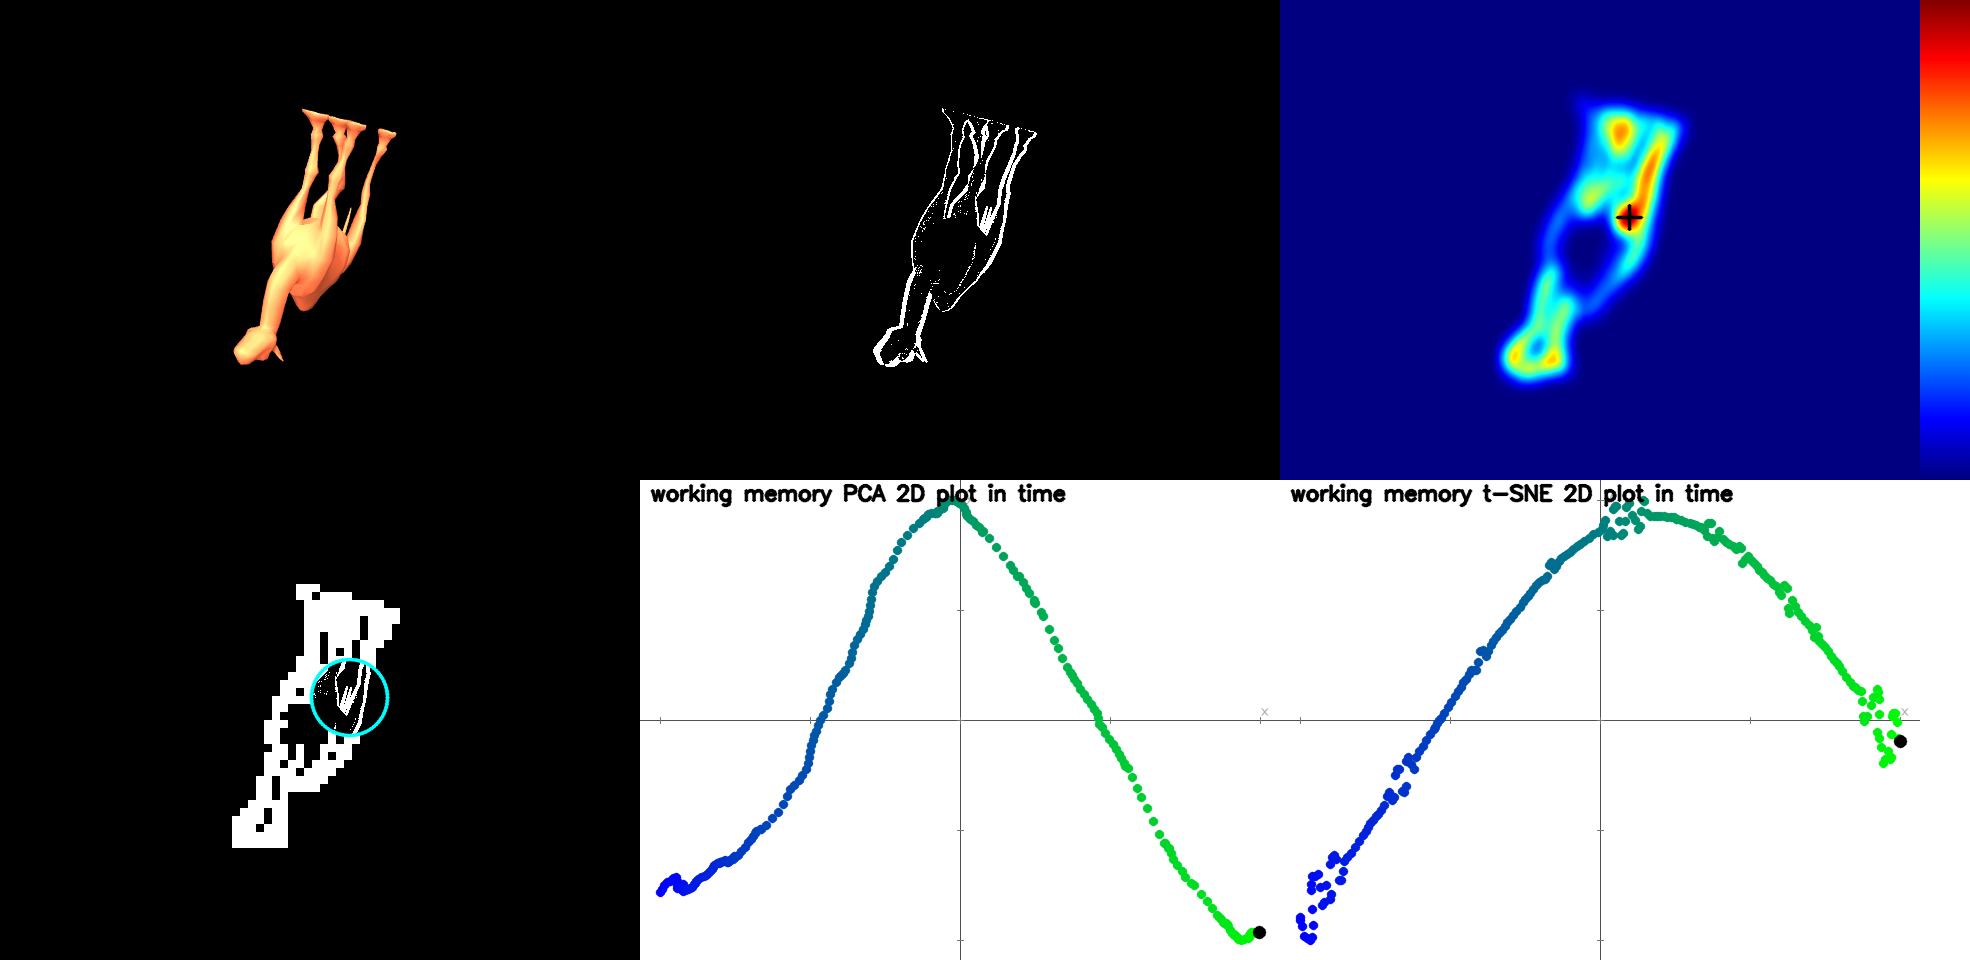

In [137]:
object_name = "camel"   # choose object from the CRIB
seed = 0                # choose random seed: controls initial rotation of the obejct + random fixations

# run:
XML = f"CRIB Data/mujoco_objects/{object_name}/{object_name}.xml"  
np.random.seed(seed)
event_renderer = EventFrameRendererWindow(WIDTH, HEIGHT, tau=1*DT_us)

# prepare object and scene
model, data, renderer, base_q = make_scene(XML, random_rotation=True, max_angle_deg=360)
frame0 = render_pose(model, data, renderer, base_q, 0, 0)
dvs.init_image(to_luminance(frame0))
seq_pitch, seq_roll = build_pitch_roll_sequence(max_deg=180, step_deg=3)

# init DINO model
dino_device = torch.device("cpu") # DINO on CPU
dino_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14', verbose=False).to(dino_device)
dino_model.eval()
dino_transform = T.Compose([
    T.Resize(224, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(224), T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# now we need to get patch + position + rotation quaternion + timestamp
# encode to SSP + update working memory
exploration_strategy = "mostsalient" # "mostsalient" or "exploratory"
mem = animate_with_memory_update(model, data, renderer, base_q, seq_pitch, seq_roll,  dino_model, dino_transform, dino_device, pause_s=0.01, DT_US = DT_us, exploration_strategy=exploration_strategy)
np.save(f"object_memories/{object_name}_memory_{exploration_strategy}_seed{seed}.npy", mem)

# Output animation:
# Illustrating the RGB object rotation, events, saliency and foveated view with plots of PCA/t-SNE of the evolution of working memory states in time 
# (checking if agent revisits the same sensory states (intuition)).

/var/folders/kr/m4j8t1_128xgpxssjq8syt7h0000gn/T/ipykernel_42690/3082848442.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis", N);


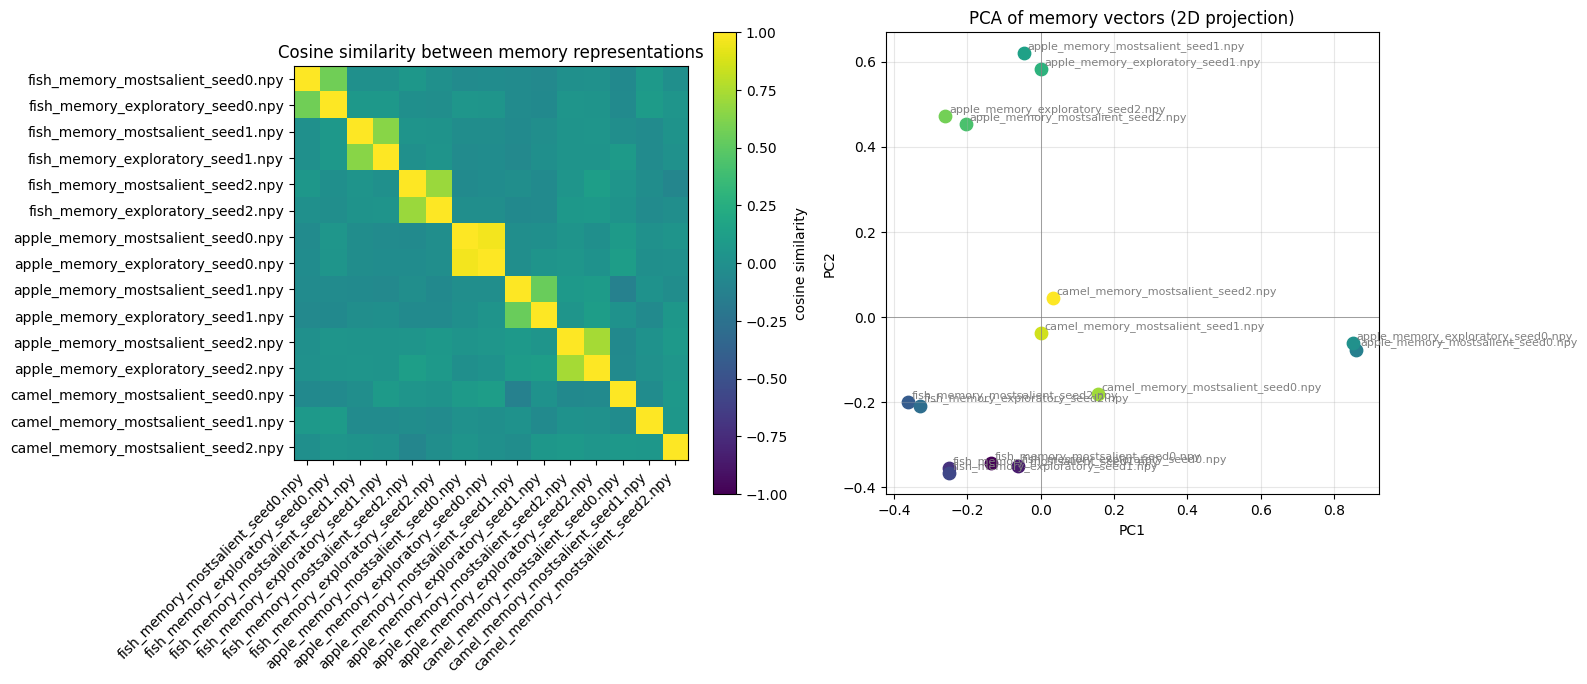

In [135]:
import matplotlib.pyplot as plt
names = ["fish_memory_mostsalient_seed0.npy","fish_memory_exploratory_seed0.npy",
         "fish_memory_mostsalient_seed1.npy", "fish_memory_exploratory_seed1.npy", 
         "fish_memory_mostsalient_seed2.npy", "fish_memory_exploratory_seed2.npy",
        "apple_memory_mostsalient_seed0.npy", "apple_memory_exploratory_seed0.npy",
        "apple_memory_mostsalient_seed1.npy", "apple_memory_exploratory_seed1.npy", 
        "apple_memory_mostsalient_seed2.npy", "apple_memory_exploratory_seed2.npy",
        "camel_memory_mostsalient_seed0.npy",
        "camel_memory_mostsalient_seed1.npy", 
        "camel_memory_mostsalient_seed2.npy"
]
mem_list = []
for name in names:
    mem = np.load(f"object_memories/{name}")
    mem = np.squeeze(mem).reshape(-1)             # remove any singleton dims; ensure 1D, shape (D,)
    mem = to_unitary_ssp(mem, n=mem.shape[0])
    mem_list.append(mem)

mems = np.stack(mem_list, axis=0)    # shape (6, D)
S = mems @ mems.T

# --- PCA to 2D ---
pca2 = PCA(n_components=2)
X2 = pca2.fit_transform(mems)   # shape (N, 2)

N = len(names)
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes
im = ax1.imshow(S, vmin=-1, vmax=1, cmap="viridis")
ax1.set_xticks(np.arange(N))
ax1.set_yticks(np.arange(N))
ax1.set_xticklabels(names, rotation=45, ha="right")
ax1.set_yticklabels(names)
cbar = plt.colorbar(im, ax=ax1)
cbar.set_label("cosine similarity")
ax1.set_title("Cosine similarity between memory representations")

cmap = plt.cm.get_cmap("viridis", N);
for i, name in enumerate(names):
    color = cmap(i) 
    x, y = X2[i, 0], X2[i, 1]
    ax2.scatter(x, y, s=80, color=color)
    ax2.text(x + 0.01, y + 0.01, name, fontsize=8, color = "gray")
ax2.set_title("PCA of memory vectors (2D projection)")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.axhline(0, color="gray", linewidth=0.5)
ax2.axvline(0, color="gray", linewidth=0.5)
ax2.grid(True, alpha=0.3)

plt.show()



# Discussion

- Exploring similarity of the object representations   
    - __Hypothesis:__ Memory vectors of different exploration runs on the same object(apple,apple) would be more similar to each other than to explorations on different objects(camel).  
    - $\rightarrow$ Not visible from the cos. similarity matrix. It seems that the position+rotation information is dominant in the encoding, because some of the memories (exploratory strategy) are somewhat similar eventhough the objects are different when sharing the initial seed.  
    - $\rightarrow$ Did PCA over the saved working memories: it seems that there is some clustering going on (but the apple memory with seed0 behaves strangely).


- Explored the effects of randomized next-saccade-point selection:
    - strategy 1) Picking always the most salient point  
    - strategy 2) 0.5 chance of picking the most salient point, 0.5 chance of randomly picking a point in the region, where saliency is > 100 (max saliency = 255)   

    $\rightarrow$ Memory vectors obtained from the exploration (mostsalient or exploratory) of the same object starting from the same initial rotation (seed) are highly similar.  

### Questions   
- The rotation is currently represented absolutely. Should it be represented only as a relative rotation? (Hoping to make memories of explorations of the same object with different seed more similar + matching proprioceptive information better.)